# Notebook 2: Math Refresher, Fundamental Functions and Calculus

*Quantitative Methods in Neuroscience, Master in Neuroscience, University of Geneva (2026-27)*

This is the practical companion to **Lecture 2, Calculus Refresher and Fundamental Functions
for Neuroscience**. The lecture introduced a small zoo of mathematical objects that come back
again and again in experimental neuroscience: exponentials, logarithms, Gaussians, sigmoids,
sines and cosines, together with the calculus used to manipulate them, derivatives and
integrals.

Here we build those functions ourselves, plot them, take them apart parameter by parameter,
and then do calculus on them **numerically**, on a computer, rather than with pen and paper.
Everything in this notebook runs on signals we generate ourselves, so there is no dataset to
load: real data arrives next week.

### By the end of this notebook you will be able to:
- Write your own Python **functions**, with arguments, defaults and a docstring.
- Evaluate a function on a grid of points with **NumPy arrays**, without writing a loop.
- Build a figure deliberately: **figure and axes**, lines, points, bars, error bars, labels,
  legends, several panels, and saving the result to a file.
- Recognise the **fundamental shapes** and say what each of their parameters does.
- Compute a **numerical derivative** and a **numerical integral**, and check them against the
  analytic answer.
- State the **Fundamental Theorem of Calculus** and verify it numerically.
- Approximate a function near a point with its **first-order Taylor expansion**, and see where
  that approximation breaks down.
- Put all of it together on two generated signals, a calcium transient and an EEG-like trace.

### Table of contents
0. [Setting up](#section-0)
1. [Functions and how to plot them](#section-1)
   - 1.1 [Defining a function](#section-1-1)
   - 1.2 [Reusing your code: a module](#section-1-2)
   - 1.3 [NumPy arrays and vectorization](#section-1-3)
   - 1.4 [Anatomy of a plot](#section-1-4)
   - 1.5 [The function zoo](#section-1-5)
2. [Calculus, numerically](#section-2)
   - 2.1 [The derivative as a local slope](#section-2-1)
   - 2.2 [The second derivative: curvature](#section-2-2)
   - 2.3 [The integral as accumulation](#section-2-3)
   - 2.4 [The Fundamental Theorem of Calculus](#section-2-4)
   - 2.5 [Local linearization: Taylor to first order](#section-2-5)
3. [Putting it together on generated signals](#section-3)
   - 3.1 [A calcium transient](#section-3-1)
   - 3.2 [An EEG-like signal](#section-3-2)
4. [What comes next](#section-4)

> **How to read this notebook.** Markdown cells like this one explain *why* we are doing
> something and the *concept* behind the maths. Code cells implement it. Look out for
> **`▶ Task`** boxes: those are short exercises where you edit or extend the code. Each task
> carries a difficulty tag:
>
> - **⭐** essential for everyone: run the code, understand it, change it slightly.
> - **⭐⭐** intermediate: repair a small bug, complete the missing lines, write a short function.
> - **⭐⭐⭐** optional challenge: build a fuller piece of analysis on your own.
>
> If you get stuck, ask the TAs. If you use AI help, treat it as a tutor and not as a
> replacement for thinking: you should still be able to read every line and explain what it
> does and why. We suggest the custom bot prepared for this course:
> https://chatgpt.com/g/g-69fc9bfc9a748191a912a124800d9254-qmn-teaching-assistant-bot

<a id="section-0"></a>
## 0. Setting up

> **Before you run anything**, make sure the course conda environment **`qmn`** is active, or
> selected as this notebook's kernel in VS Code. If you have not created it yet, follow the
> illustrated setup guide (`QMN_setup_guide_students.pdf`) or `SETUP_INSTRUCTIONS.txt`, both in
> the course folder.

In [1]:
# Where the data and the shared helpers live. This works whether the notebook
# is opened from notebooks/ or from a subfolder of it.
import sys
from pathlib import Path

# sys.path is the list of folders Python searches when you import something. Adding ROOT to it
# is what lets `from src.qmn_utils import ...` work further down, whatever folder you started in.

ROOT = Path.cwd() if (Path.cwd() / "data").is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
print("ROOT =", ROOT)

ROOT = C:\Users\matteucc\Documents\QMN_course\notebooks


In [2]:
# --- Import the scientific Python stack
import numpy as np                  # import of Numpy library: numerical arrays and maths
import matplotlib.pyplot as plt     # import of Matplotlib library: plotting
from cycler import cycler           # to set our own default colour sequence

# A bit of style for every figure in this notebook (feel free to tweak it)
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.prop_cycle": cycler(color=[
        "#1f77b4",  # blue
        "#ff7f0e",  # orange
        "#5b2c83",  # purple
    ]),
})

print(f"NumPy      : {np.__version__}")
print(f"matplotlib : {plt.matplotlib.__version__}")

NumPy      : 2.3.5
matplotlib : 3.10.9


<a id="section-1"></a>
# Part 1. Functions and how to plot them

Three things, in the order in which each one needs the one before it: how to write a
**function**, how to hold a lot of numbers at once in an **array**, and how to **plot** the
result. By the end of this part you will have defined a function, evaluated it on a grid of
points, and drawn it.

<a id="section-1-1"></a>
## 1.1 Defining a function

A **function** is a reusable block of code: you give it inputs (its *arguments*) and it hands
back a result with `return`. Think of it as a small machine. Functions are the main tool we
have for not repeating ourselves: if you catch yourself copy-pasting a calculation, that is the
signal to turn it into a function. Then a change of mind means editing one place instead of
five.

The `"""` line just under `def` is the **docstring**: one sentence saying what the function
does. Write one every time. In six weeks it will be you reading it.

In [3]:
# --- A very first function
def square(x):
    """Return x squared."""
    return x * x

print(square(3))       # 9
print(square(0.5))     # 0.25

9
0.25


Arguments can have **default values**, used whenever the caller does not supply them. Here is
the logistic sigmoid from the lecture, which we will meet again as a psychometric curve in
Week 3:

$$\sigma(x; \, k, x_0) \;=\; \frac{1}{1 + e^{-k\,(x - x_0)}}$$

with $k$ controlling how steep the S is, and $x_0$ shifting it left or right.

One thing in the code below is borrowed from the next section: `np.exp` is NumPy's exponential function, $e^x$. For now read it as "e to the power of", and section 1.3 explains where `np` comes from and why we use its version rather than the one in the standard library.

In [4]:
# --- A logistic sigmoid, with defaults for slope and bias
def sigmoid(x, slope=1.0, bias=0.0):
    """Logistic sigmoid with adjustable slope and horizontal bias."""
    return 1.0 / (1.0 + np.exp(-slope * (x - bias)))

print(sigmoid(0.0))                  # 0.5 by construction
print(sigmoid(10.0))                 # almost 1
print(sigmoid(10.0, slope=0.1))      # much less, the curve is flatter

0.5
0.9999546021312976
0.7310585786300049


<a id="section-1-2"></a>
## 1.2 Reusing your code: a module

Right now `sigmoid` lives inside this notebook. That is fine for one afternoon, but the same function is wanted again in
Week 3, and copy-pasting a definition between notebooks is the easiest way to end up with two
versions that quietly disagree.

The standard practice in every real Python project is to put reusable helpers in a `.py` file,
a **module**, and import it just like NumPy. Those are the words from Week 1 section 4: a module is
one file of Python code, a library is a collection of modules installed together. Here we write our
own module instead of importing somebody else's. We keep ours in `src/qmn_utils.py`, next to the
notebooks. The cell below prints what is currently in it.

In [5]:
# --- What is inside src/qmn_utils.py

print((ROOT / "src" / "qmn_utils.py").read_text())

"""Reusable helper functions for the QMN course notebooks.

Import the helpers you need with, e.g.:

    from src.qmn_utils import sigmoid

Add new functions here whenever you find yourself rewriting the same code
in two different notebooks — that's the signal to "promote" it from an
inline cell to a proper module function.
"""

import numpy as np


def sigmoid(x, slope=1.0, bias=0.0):
    """Logistic sigmoid with adjustable slope and horizontal bias.

    sigma(x; slope, bias) = 1 / (1 + exp(-slope * (x - bias)))
    """
    return 1.0 / (1.0 + np.exp(-slope * (x - bias)))


def my_gaussian(x, mu, sigma): # TO BE REMOVED
    """Return the un-normalized Gaussian evaluated at x.""" # TO BE REMOVED
    gauss = np.exp(-0.5 * ((x - mu) / sigma) ** 2) # TO BE REMOVED
    return gauss # TO BE REMOVED


In [6]:
# --- Import from our own module, and check it agrees with the version defined above
from src.qmn_utils import sigmoid as sigmoid_from_module

# `assert` checks that a condition is true and does nothing if it is. If it is false the cell
# stops with an AssertionError and prints the message after the comma. It is how you make a
# check loud instead of hoping somebody notices a wrong number further down.
for value in [-2.0, 0.0, 2.0]:
    assert abs(sigmoid(value) - sigmoid_from_module(value)) < 1e-12, f"differ at x={value}"
print("the notebook sigmoid and the module sigmoid agree")

the notebook sigmoid and the module sigmoid agree


<a id="section-1-3"></a>
## 1.3 NumPy arrays and vectorization

In Week 1 you met the **list**, Python's general-purpose container. A list will happily hold
numbers, but it does not do arithmetic with them: multiplying a list by 2 gives you a longer
list, not bigger numbers. To do maths on every element you have to write a loop or a list
comprehension, which is fine for four numbers and painful for four hundred.

[NumPy](https://numpy.org/) is the library that fixes this, and it is the foundation of essentially all scientific
Python. Its central object is the **array**: a grid of numbers, all of the same type, that
behaves like a number when you do arithmetic with it. We imported it at the top of the notebook under the alias `np`:

```python
import numpy as np
```

The cell below shows the difference in four lines.

In [7]:
# --- Why an array rather than a list?
numbers_list = [1.0, 2.0, 3.0, 4.0]
numbers_array = np.array(numbers_list)      # np function to convert a list into an array

print("the list  :", numbers_list)
print("the array :", numbers_array)

# Multiplying a LIST by 2 repeats it: that is Python's definition, not a mistake.
print("\nlist  * 2 :", numbers_list * 2)

# To double each element of a list you need a comprehension
print("with a comprehension:", [value * 2 for value in numbers_list])

# Multiplying an ARRAY by 2 doubles every element, with no loop at all.
print("\narray * 2 :", numbers_array * 2)
print("array + array :", numbers_array + numbers_array)
# np function to compute the exponential of each element of an array
print("np.exp(array) :", np.exp(numbers_array).round(3))

the list  : [1.0, 2.0, 3.0, 4.0]
the array : [1. 2. 3. 4.]

list  * 2 : [1.0, 2.0, 3.0, 4.0, 1.0, 2.0, 3.0, 4.0]
with a comprehension: [2.0, 4.0, 6.0, 8.0]

array * 2 : [2. 4. 6. 8.]
array + array : [2. 4. 6. 8.]
np.exp(array) : [ 2.718  7.389 20.086 54.598]


That last line is the important one. `np.exp` applied to an array returns an array, with the
function applied to every element. Doing maths on a whole array at once, with no loop, is called
**vectorization**, and it is both faster and easier to read than the loop it replaces.

Now let us build the grid of x values we need in order to plot a function. We will do it the
long way first, with the comprehension you already know, and then convert the result into an
array.

In [8]:
# --- Define the grid as a Python list first
n_points = 201
x_min = -1.0
x_max = 1.0
step = (x_max - x_min) / (n_points - 1)
x_grid_list = [x_min + i * step for i in range(n_points)]

# --- Convert the Python list into a NumPy array
x_grid = np.array(x_grid_list)

# --- Evaluate the sigmoid on the whole NumPy array in one shot
y_grid = sigmoid(x_grid, slope=8.0)

print("x_grid type  :", type(x_grid)) # get info on the type of object
print("x_grid shape :", x_grid.shape) # get info on the shape of the numpy array
print("y_grid shape :", y_grid.shape)
# "slice" the array to get every 50th point, and round to 2 decimal places
print("x, every 50th point :", x_grid[::50].round(2))
print("sigmoid there       :", y_grid[::50].round(3))

x_grid type  : <class 'numpy.ndarray'>
x_grid shape : (201,)
y_grid shape : (201,)
x, every 50th point : [-1.  -0.5  0.   0.5  1. ]
sigmoid there       : [0.    0.018 0.5   0.982 1.   ]


Two things to notice in that output.

**`.shape`** tells you the size of an array. Here it is `(201,)`, meaning one dimension of 201
numbers. Shapes become important later, when arrays have rows and columns.

**Slicing works exactly as it does for lists.** `x_grid[::50]` means "every 50th element", which
is why the printout shows five points spread across the range instead of 201 numbers. When slicing an array the three numbers are start, stop and step. Here the start and the stop are
left empty, which means the whole array, and the step is 50.

And now the shortcut. Building a grid by hand is a useful thing to do once, so that you know what
is in it, but NumPy has a function for precisely this job: `np.linspace(start, stop, n)` returns
`n` evenly spaced points from `start` to `stop`, inclusive. From here on we will always use it.

In [9]:
# --- The same grid, in one line
x_grid_quick = np.linspace(-1.0, 1.0, 201)

print("first three values :", x_grid_quick[:3])
print("last three values  :", x_grid_quick[-3:])
print("identical to the hand-built grid?", np.allclose(x_grid_quick, x_grid))

# The sigmoid we wrote in 1.1 is built only from NumPy operations, so it is vectorized for free:
# calling it on an array of 201 values returns an array of 201 values, no loop required.
print("\nsigmoid applied to the whole grid gives", sigmoid(x_grid_quick).shape, "values")

first three values : [-1.   -0.99 -0.98]
last three values  : [0.98 0.99 1.  ]
identical to the hand-built grid? True

sigmoid applied to the whole grid gives (201,) values


<a id="section-1-4"></a>
## 1.4 Anatomy of a plot

Humans are very visual animals and "a picture is worth a thousand words". Almost everything in 
this course gets checked by looking at a picture rather than raw numbers, so it is worth spending 
a little time on the vocabulary before we draw anything. This is also how we will visualise functions
like the sigmoid we defined above.

For plotting we use [Matplotlib](https://matplotlib.org/), the standard Python library for
figures, imported at the top of this notebook under the alias `plt`:

```python
import matplotlib.pyplot as plt
```

Matplotlib works with **objects**, in the sense of Week 1 section 7.2: things that carry their own
data (attributes) and their own commands (methods, called with a dot and parentheses). You will
write `ax.set_xlabel(...)` for the same reason you wrote `my_list.append(...)`. There are two such
objects you will handle all the time:

- the **figure** is the whole canvas, the thing that gets saved to a file;
- the **axes** is one set of x and y coordinates drawn inside it, with its own labels, its own
  title and its own data (typically represented by the vertical and horizontal "rulers" on the bottom 
  and left sides of a typical figure panel). A figure can hold several "frames" with different axes,
  which is what people mean by "panels" or "subplots".


One confusing detail: the matplotlib object called "axes" is a single object, not the plural
of "axis". The x axis and the y axis are parts *of* an axes.

The figure below is from the matplotlib documentation and it is the single most useful reference
you will meet this week: it names every element of a plot and, next to each name, the method that
creates it. Keep it open while you work.

<img src="assets/02/matplotlib_anatomy.png" width="620">

*Anatomy of a figure, from the [matplotlib documentation](https://matplotlib.org/stable/gallery/showcase/anatomy.html), reproduced under the matplotlib licence.*

### Your first plot

Every figure in this course starts with the same line: `plt.subplots()` creates a figure and one
axes, and hands **both** back to you at once (as a tuple). Two names on the left of the `=`, separated by a
comma, is the tuple unpacking from Week 1 section 7.4: the function returns a pair, and the two
names take one element each. After that you talk to `ax` when you want to change what is inside
the panel, and to `fig` when you want to change the whole canvas.

`plt.subplots` takes a good number of optional arguments, and its
[documentation page](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) is
worth opening once now, if only to see what the reference page of a function you use every day
looks like.

Three lines is the minimum:

```python
fig, ax = plt.subplots()    # make a figure with one axes
ax.plot(x, y)               # draw a line on that axes
plt.show()                  # display it
```

Let us run exactly that.

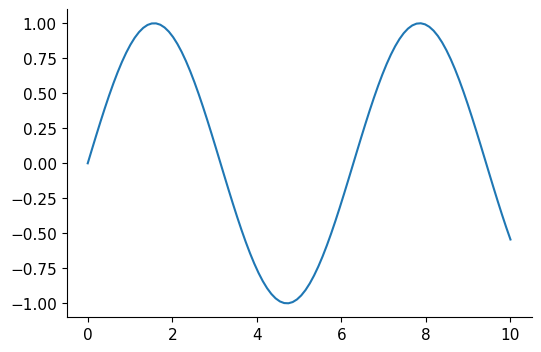

In [10]:
# --- The smallest possible plot: a line
x = np.linspace(0, 10, 100)     # 100 evenly spaced numbers from 0 to 10
y = np.sin(x)                   # the sine of each of them

fig, ax = plt.subplots()        # a figure containing one axes
ax.plot(x, y)                   # draw y against x, joined up as a line
plt.show()                      # show the result

### A second kind: the scatter

`ax.plot` joins the points with a line, which is what you want for something measured on a fine
grid, like a signal over time. When each point is a separate observation, you usually want a
**scatter**: one marker per data point and no line between them. The method is `ax.scatter`, and
everything else stays the same.

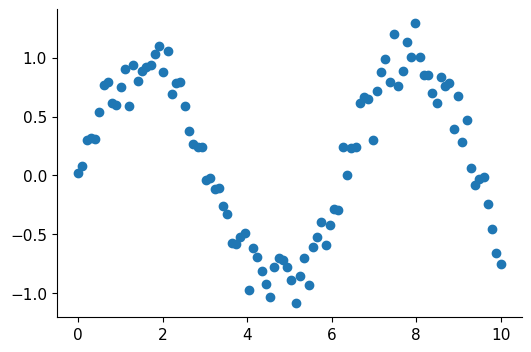

In [11]:
# --- The same idea, one marker per observation
rng = np.random.default_rng(0)          # a random-number generator, more on this in Week 3
noise = rng.normal(0, 0.15, size=x.size)   # a little random jitter, one value per point

fig, ax = plt.subplots() # generate a figure and axes object for plotting
ax.scatter(x, y + noise) # markers instead of a line
plt.show()

### A third kind: the histogram

The two above show each observation. A **histogram** throws that detail away and shows how the
values are *distributed*: it chops the range into bins and counts how many values fall in each.
It is the workhorse of Week 3.

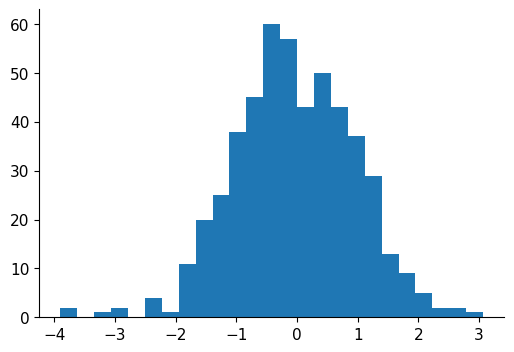

In [12]:
# --- How are the values distributed?
values = rng.normal(0, 1, size=500)     # 500 random numbers

fig, ax = plt.subplots()
ax.hist(values, bins=25)                # 25 bins across the range
plt.show()

### Making a plot readable

A plot without labels is not a result, it is a doodle. The minimum any figure of yours should
carry is an **x label** and a **y label** with units, a **title** or a caption, and a **legend**
whenever more than one thing is drawn on the same axes.

The cell below takes the very first line plot and adds one thing at a time. Read it top to
bottom and match each line against the anatomy figure above.

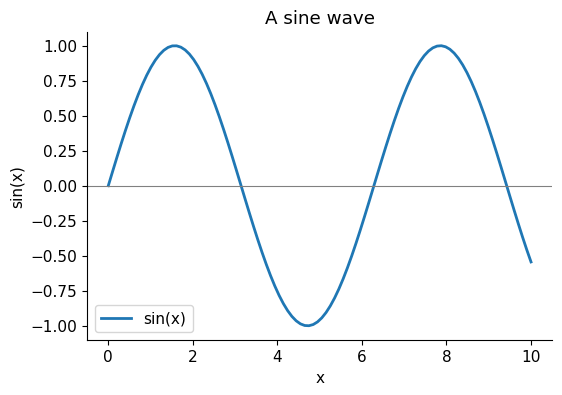

In [13]:
# --- The same line, dressed one element at a time
fig, ax = plt.subplots()

# colour, line width, and a name for the legend
ax.plot(x, y, color="#1f77b4", lw=2, label="sin(x)")
ax.set_xlabel("x")                                     # what the horizontal axis means
ax.set_ylabel("sin(x)")                                # what the vertical axis means
ax.set_title("A sine wave")                            # what the panel shows
ax.legend()                                            # show the labels of everything drawn
ax.axhline(0, color="gray", lw=0.8)                    # a horizontal reference line at y = 0

plt.show()

The cell below draws a decaying oscillation. Run it, then read the task under it.

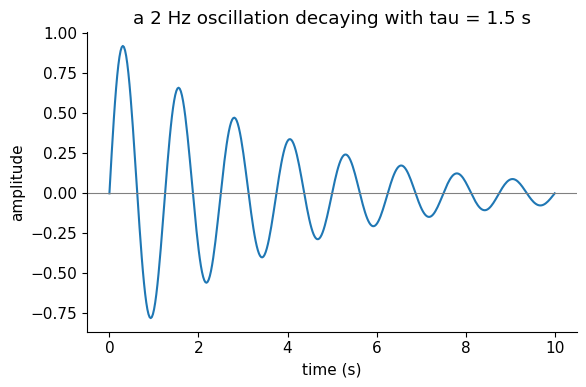

In [14]:
t_signal = np.linspace(0, 4, 400)                  # four seconds, 400 samples
signal = np.exp(-t_signal / 1.5) * np.sin(2 * np.pi * 2.0 * t_signal)

t_axis = np.linspace(0, 10, 400)                   # the grid used for the x axis

fig, ax = plt.subplots()
ax.plot(t_axis, signal, lw=1.5)
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("time (s)")
ax.set_ylabel("amplitude")
ax.set_title("a 2 Hz oscillation decaying with tau = 1.5 s")
fig.tight_layout()
plt.show()

> **▶ Task 1.1 ⭐⭐ - Repair the figure.**
> The figure above runs without an error and looks entirely plausible, and it is wrong: the picture
> does not show what the labels claim.
>
> Compare the x axis with the data being plotted, write a corrected version below, and say in a
> comment what gave the bug away.

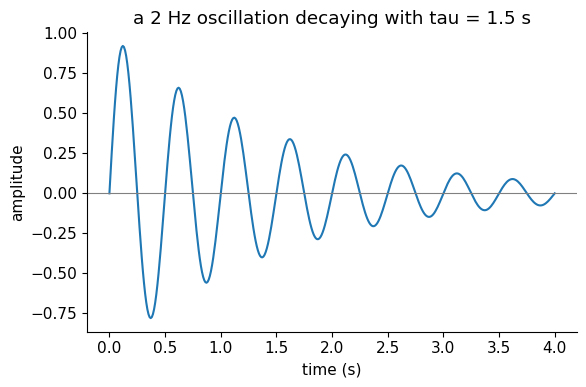

In [15]:
# TODO 1.1 - your corrected figure here

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
# The bug: the curve is drawn against `t_axis`, which runs to 10 s, while the values were computed
# on `t_signal`, which runs to 4 s. Matplotlib does not mind, because both arrays have 400 points,
# so it stretches four seconds of signal across ten seconds of axis. Nothing complains and the
# picture is wrong.
#
# What gives it away: the title says 2 Hz, so there should be two full cycles per second and eight
# in the four seconds of signal. Count the cycles in the broken figure and they are spread over
# what the axis calls ten seconds, which would make it 0.8 Hz. Reading a number off your own
# figure and checking it against what you meant to draw is the habit this exercise is for.
fig, ax = plt.subplots()
ax.plot(t_signal, signal, lw=1.5)
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("time (s)")
ax.set_ylabel("amplitude")
ax.set_title("a 2 Hz oscillation decaying with tau = 1.5 s")
fig.tight_layout()
plt.show()
# --- END SOLUTION


### Several panels in one figure

So far every figure has had exactly one axes. Asking `plt.subplots` for a grid gives you several,
and then `axes` is an array you index like any other: `axes[0, 1]` is the top-right panel.

That is the only new idea in the cell below. It draws the four plot types you will use most, one
per panel, so you can see them side by side.

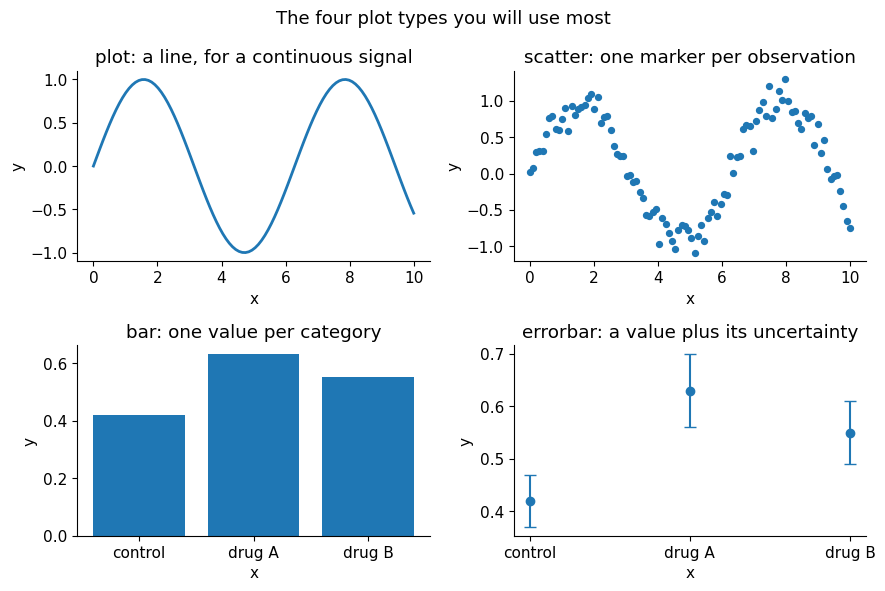

In [16]:
# --- Four plot types, one per panel
# First the data, so that the plotting code below stays easy to read.
noisy_y = y + noise                                 # from the scatter example above
groups = ["control", "drug A", "drug B"]            # three experimental conditions
means = [0.42, 0.63, 0.55]                          # their average outcome
errors = [0.05, 0.07, 0.06]                         # and the uncertainty on each average

fig, axes = plt.subplots(2, 2, figsize=(9, 6))      # a 2x2 grid: axes is now an array

axes[0, 0].plot(x, y, lw=2) # lw is the line width
axes[0, 0].set_title("plot: a line, for a continuous signal")

axes[0, 1].scatter(x, noisy_y, s=18) # s is the marker size
axes[0, 1].set_title("scatter: one marker per observation")

axes[1, 0].bar(groups, means, color="#1f77b4") # color is the fill colour of the bars
axes[1, 0].set_title("bar: one value per category")

# yerr is the uncertainty, fmt is the marker style, capsize is the width of the error bar caps
axes[1, 1].errorbar(groups, means, yerr=errors, fmt="o", capsize=4)
axes[1, 1].set_title("errorbar: a value plus its uncertainty")

for ax in axes.flat:            # loop over all four panels and label them
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.suptitle("The four plot types you will use most", fontsize=13)
fig.tight_layout()              # stops the panels from overlapping each other
plt.show()

### Saving a figure

`fig.savefig` writes the figure to a file. This is how a plot leaves the notebook and ends up in
a report, a slide or a paper, and `dpi` controls how many pixels per inch it gets.

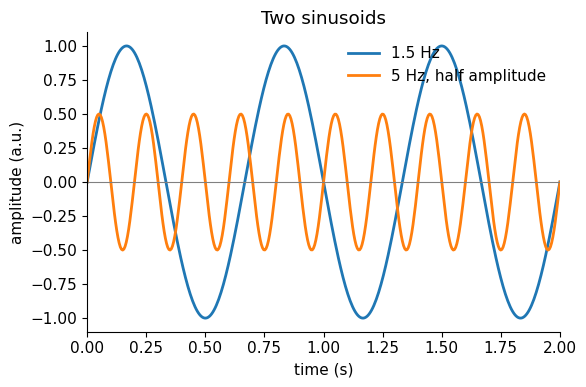

saved figure_two_sinusoids.png


In [17]:
# --- A finished figure, saved to a file
t = np.linspace(0, 2, 400)
slow = np.sin(2 * np.pi * 1.5 * t)
fast = 0.5 * np.sin(2 * np.pi * 5.0 * t)

fig, ax = plt.subplots()
ax.plot(t, slow, lw=2, label="1.5 Hz")
ax.plot(t, fast, lw=2, label="5 Hz, half amplitude")
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("time (s)")
ax.set_ylabel("amplitude (a.u.)")
ax.set_title("Two sinusoids")
ax.set_xlim(0, 2)
ax.legend(loc="upper right", frameon=False)
fig.tight_layout()
fig.savefig("figure_two_sinusoids.png", dpi=150)   # written next to this notebook
plt.show()
print("saved figure_two_sinusoids.png")

> **▶ Task 1.2 ⭐ - Make the figure yours.**
> Copy the cell above into the empty cell below and change it so that:
> 1. the two lines are dashed rather than solid (look up the `ls` argument of `ax.plot`);
> 2. the legend sits in the lower left;
> 3. the file is saved as `my_first_figure.png`.

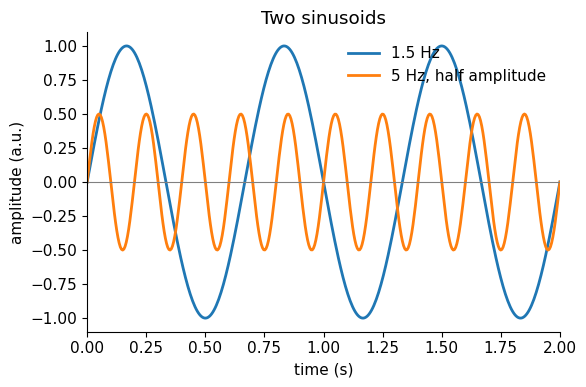

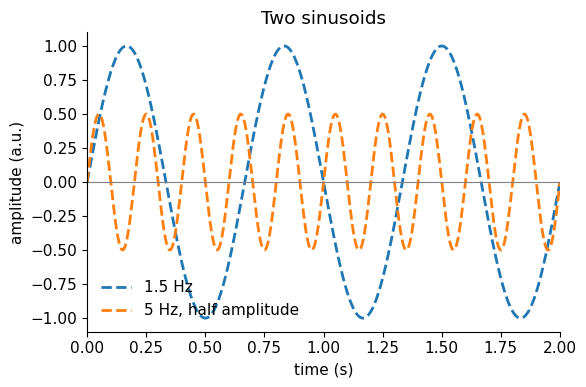

In [18]:
# TODO 1.2 - the working figure is below. Change the three marked lines, then run the cell.
fig, ax = plt.subplots()
ax.plot(t, slow, lw=2, label="1.5 Hz")                  # (1) make this line dashed (see `ls`)
ax.plot(t, fast, lw=2, label="5 Hz, half amplitude")    # (1) and this one too
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("time (s)")
ax.set_ylabel("amplitude (a.u.)")
ax.set_title("Two sinusoids")
ax.set_xlim(0, 2)
ax.legend(loc="upper right", frameon=False)             # (2) move the legend to the lower left
fig.tight_layout()
fig.savefig("figure_two_sinusoids.png", dpi=150)        # (3) save it as my_first_figure.png
plt.show()

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
fig, ax = plt.subplots()
ax.plot(t, slow, lw=2, ls="--", label="1.5 Hz")
ax.plot(t, fast, lw=2, ls="--", label="5 Hz, half amplitude")
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("time (s)")
ax.set_ylabel("amplitude (a.u.)")
ax.set_title("Two sinusoids")
ax.set_xlim(0, 2)
ax.legend(loc="lower left", frameon=False)
fig.tight_layout()
fig.savefig("my_first_figure.png", dpi=150)
plt.show()
# --- END SOLUTION

<a id="section-1-5"></a>
## 1.5 The function zoo

Five shapes cover most of what you will meet. For each one, the thing to learn is not the
formula but **what each parameter does to the picture**.

### Exponential and logarithm

The exponential $e^{ax}$ grows (or decays, if $a<0$) by a constant *factor* per unit of x. The
logarithm is its inverse: it undoes it. Because of that, plotting an exponential on a
**logarithmic y axis** turns it into a straight line, and the slope of that line is the rate.
That is the single most useful diagnostic plot in this section: if your data look straight on a
log axis, an exponential is a good model for them.

The third panel below uses **`ax.semilogy`**, which is simply `ax.plot` with the y axis already set
to a logarithmic scale. It is one call instead of two, and everything else about it behaves like a
normal plot. (`ax.semilogx` and `ax.loglog` do the same for the other axis and for both.)

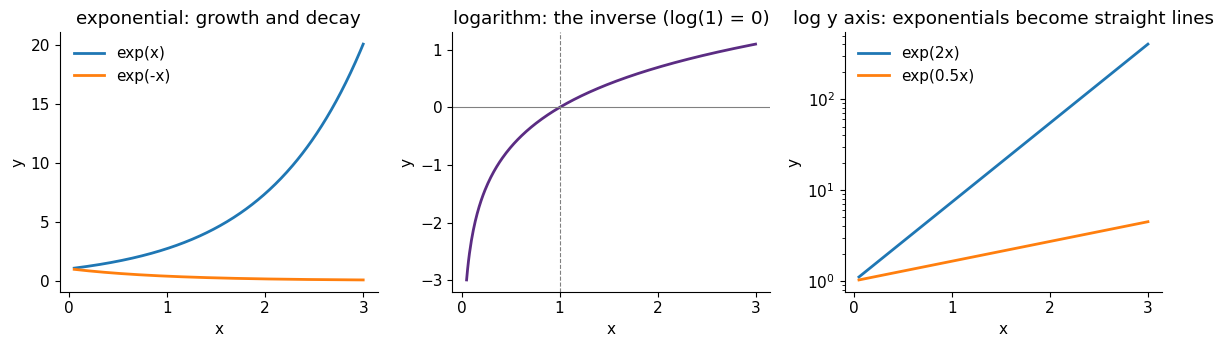

In [19]:
# --- Exponential and logarithm, on linear and on log axes
x = np.linspace(0.05, 3, 300)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))

axes[0].plot(x, np.exp(x), lw=2, label="exp(x)")
axes[0].plot(x, np.exp(-x), lw=2, label="exp(-x)")
axes[0].set_title("exponential: growth and decay") # set the title of the panel
axes[0].legend(frameon=False) # remove the box around the legend

axes[1].plot(x, np.log(x), lw=2, color="#5b2c83")
axes[1].axhline(0, color="gray", lw=0.8) # horizontal reference line at y = 0
axes[1].axvline(1, color="gray", lw=0.8, ls="--") # vertical reference line at x = 1
axes[1].set_title("logarithm: the inverse (log(1) = 0)")

axes[2].semilogy(x, np.exp(2 * x), lw=2, label="exp(2x)")
axes[2].semilogy(x, np.exp(0.5 * x), lw=2, label="exp(0.5x)")
axes[2].set_title("log y axis: exponentials become straight lines")
axes[2].legend(frameon=False)

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
fig.tight_layout()
plt.show()

### Exponential decay

The workhorse of the course. Written with the parameters you actually care about:

$$f(t) \;=\; b + A\,e^{-t/\tau}$$

- $b$ is the **baseline**, the value the signal settles to;
- $A$ is the **amplitude**, how far above baseline it starts;
- $\tau$ (tau) is the **time constant**, in the same units as $t$. After one $\tau$ the signal
  has fallen to $1/e \approx 37\%$ of its initial displacement; after $3\tau$ it is at about 5%.

A quantity you will see in papers is the **half-life**, the time to fall halfway:
$t_{1/2} = \tau \ln 2 \approx 0.69\,\tau$.

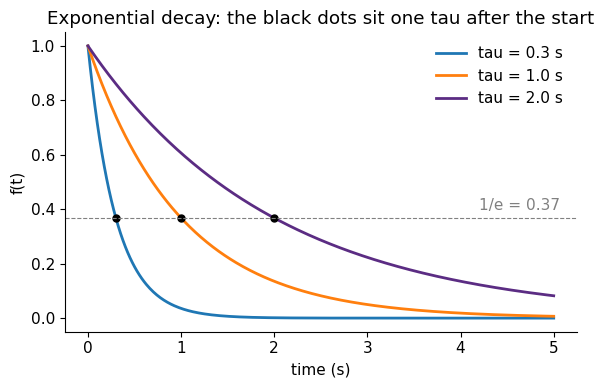

half-life for tau = 1 s: 0.693 s


In [20]:
# --- Exponential decay for three time constants, with tau and the half-life marked
def exp_decay(t, amplitude=1.0, tau=1.0, baseline=0.0):
    """Exponential decay from baseline + amplitude towards baseline, with time constant tau."""
    return baseline + amplitude * np.exp(-t / tau)

t = np.linspace(0, 5, 400)

fig, ax = plt.subplots()
for tau in [0.3, 1.0, 2.0]:
    # "lw" is the line width, "label" is the name for the legend
    ax.plot(t, exp_decay(t, tau=tau), lw=2, label=f"tau = {tau} s")
    # "o" is the marker style for a filled circle, ms is the marker size
    ax.plot(tau, exp_decay(tau, tau=tau), "o", color="black", ms=5)

ax.axhline(np.exp(-1), color="gray", lw=0.8, ls="--") # horizontal reference line at y = 1/e
# add a text label to the panel, at the given coordinates, in gray
ax.text(4.2, np.exp(-1) + 0.03, "1/e = 0.37", color="gray")
ax.set_xlabel("time (s)") # set the label of the horizontal axis
ax.set_ylabel("f(t)") # set the label of the vertical axis
ax.set_title("Exponential decay: the black dots sit one tau after the start")
ax.legend(frameon=False)
# a good habit even with a single panel: it keeps things from overlapping if the figure
# is resized
fig.tight_layout()
plt.show()

print(f"half-life for tau = 1 s: {1.0 * np.log(2):.3f} s")

### The Gaussian

$$g(x) \;=\; b + A\,\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

- $\mu$ is the **centre**, where the peak sits;
- $\sigma$ is the **width**, the spread on either side;
- $A$ the **amplitude** and $b$ the **baseline**, as before.

Experimentalists usually quote the width as the **full width at half maximum** (FWHM), the
width of the bump measured halfway up. It relates to sigma by
$\text{FWHM} = 2\sqrt{2\ln 2}\,\sigma \approx 2.355\,\sigma$.

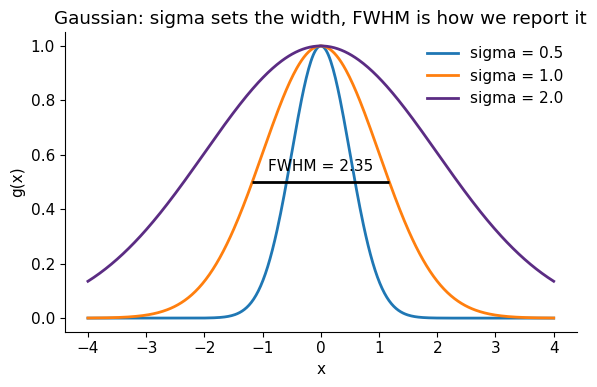

In [21]:
# --- A Gaussian with its FWHM drawn on top
def gaussian(x, mu=0.0, sigma=1.0, amplitude=1.0, baseline=0.0):
    """Gaussian bump centred on mu with width sigma (not normalised to unit area)."""
    return baseline + amplitude * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

x = np.linspace(-4, 4, 400)
mu, sigma = 0.0, 1.0
fwhm = 2 * np.sqrt(2 * np.log(2)) * sigma

fig, ax = plt.subplots()
for s in [0.5, 1.0, 2.0]:
    ax.plot(x, gaussian(x, sigma=s), lw=2, label=f"sigma = {s}")

# add horizontal line at half maximum
ax.hlines(0.5, mu - fwhm / 2, mu + fwhm / 2, color="black", lw=2)
# add a text label to the panel, at the given coordinates, horizontally aligned to the center
ax.text(mu, 0.54, f"FWHM = {fwhm:.2f}", ha="center")
ax.set_xlabel("x")
ax.set_ylabel("g(x)")
ax.set_title("Gaussian: sigma sets the width, FWHM is how we report it")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

### The sigmoid, again

$$\sigma(x;k,x_0) = \frac{1}{1+e^{-k(x-x_0)}}$$

- $x_0$ is the **midpoint**, where the curve passes through one half. It is also the
  **inflexion point**, where the curve stops bending one way and starts bending the other.
- $k$ is the **slope** or sensitivity: the steepness at the midpoint is $k/4$.

In Week 3 this same curve becomes the **psychometric function**, with x the strength of a
stimulus and y the probability of a particular choice. Then $x_0$ is the animal's threshold and
$k$ is how sharply it discriminates.

### Sine and cosine

$$s(t) = b + A\sin(2\pi f t + \varphi)$$

- $A$ is the **amplitude**, $b$ the **baseline**;
- $f$ is the **frequency** in hertz, cycles per second, and $1/f$ is the period;
- $\varphi$ is the **phase**, a shift along the time axis.

Cosine is a sine shifted by a quarter of a cycle. Both appear the moment we look at rhythms,
which is what the EEG weeks at the end of the course are about.

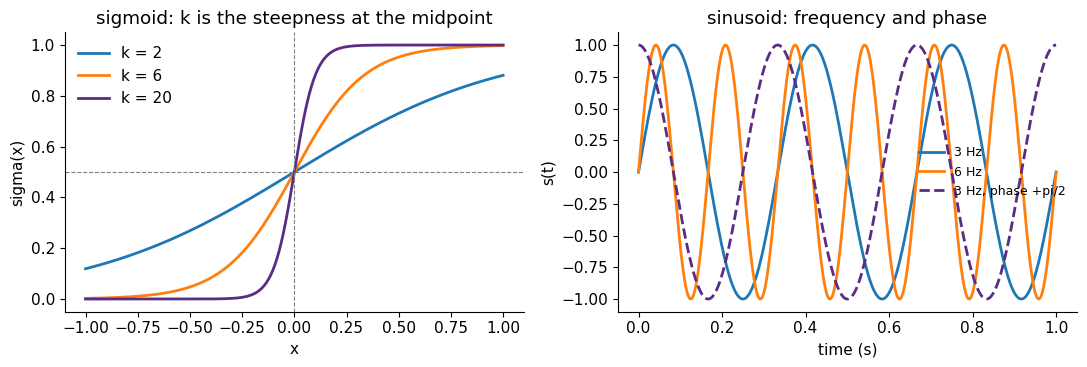

In [22]:
# --- Sigmoid slope family and sinusoid parameter family, side by side
x = np.linspace(-1, 1, 400)
t = np.linspace(0, 1, 500)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

for k in [2, 6, 20]:
    axes[0].plot(x, sigmoid(x, slope=k), lw=2, label=f"k = {k}")
axes[0].axhline(0.5, color="gray", lw=0.8, ls="--") # add a horizontal reference line at y = 0.5
axes[0].axvline(0.0, color="gray", lw=0.8, ls="--") # add a vertical reference line at x = 0
# set the label of the horizontal and vertical axes
axes[0].set_xlabel("x"); axes[0].set_ylabel("sigma(x)")
axes[0].set_title("sigmoid: k is the steepness at the midpoint")
axes[0].legend(frameon=False)

axes[1].plot(t, np.sin(2 * np.pi * 3 * t), lw=2, label="3 Hz")
axes[1].plot(t, np.sin(2 * np.pi * 6 * t), lw=2, label="6 Hz")
axes[1].plot(t, np.sin(2 * np.pi * 3 * t + np.pi / 2), lw=2, ls="--",
             label="3 Hz, phase +pi/2")
axes[1].set_xlabel("time (s)"); axes[1].set_ylabel("s(t)")
axes[1].set_title("sinusoid: frequency and phase")
# remove the box around the legend, and make the font a bit smaller so it fits
axes[1].legend(frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

> **▶ Task 1.3 ⭐ - Predict, then check.**
> In the cell below, plot the exponential decay `exp_decay` (you can copy and modify
> from the cell above) for `tau = 0.5` and `tau = 1.5` on the same axes, 
> over `t` from 0 to 4 seconds, with a legend and axis labels.
>
> Before you run it, answer in a comment: at `t = 1.5 s`, which of the two curves is higher,
> and roughly by how much? Then compute the two values and see whether you were right.

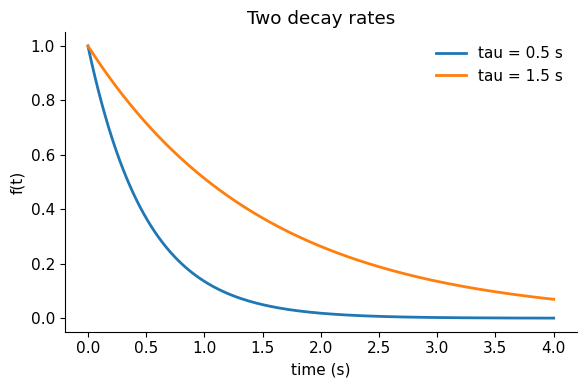

at t = 1.5 s: tau=0.5 gives 0.050, tau=1.5 gives 0.368


In [23]:
# TODO 1.3 - fill in the two blanks marked ____, uncomment, and run.
# My prediction: at t = 1.5 s the higher curve is the one with tau = ...,
#                by roughly a factor of ...

# t = np.linspace(0, 4, 400)
#
# fig, ax = plt.subplots()
# for tau in [____, ____]:                    # (1) the two time constants, 0.5 s and 1.5 s
#     ax.plot(t, exp_decay(t, tau=tau), lw=2, label=f"tau = {tau} s")
# ax.set_xlabel("time (s)")
# ax.set_ylabel("f(t)")
# ax.set_title("Two decay rates")
# ax.legend(frameon=False)
# fig.tight_layout()
# plt.show()
#
# (2) now check your prediction against the numbers
# print("at t = 1.5 s:", exp_decay(1.5, tau=____), exp_decay(1.5, tau=____))

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
# Prediction: the tau = 1.5 curve is higher. At t = 1.5 s it has decayed by exactly one time
# constant, so it sits at 1/e = 0.37, while the tau = 0.5 curve has been through three time
# constants and sits near 0.05. So roughly seven times higher.
t = np.linspace(0, 4, 400)

fig, ax = plt.subplots()
for tau in [0.5, 1.5]:
    ax.plot(t, exp_decay(t, tau=tau), lw=2, label=f"tau = {tau} s")
ax.set_xlabel("time (s)")
ax.set_ylabel("f(t)")
ax.set_title("Two decay rates")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"at t = 1.5 s: tau=0.5 gives {exp_decay(1.5, tau=0.5):.3f}, "
      f"tau=1.5 gives {exp_decay(1.5, tau=1.5):.3f}")
# --- END SOLUTION

### One last exercise, which pulls Part 1 together

That is the zoo. Before moving on to calculus, here is an exercise that uses three of the things
you have met in this part at once: you will take one of these shapes, write it into **your own
module** the way section 1.2 did with the sigmoid, import it back, and **plot** it.

One technical detail first, because it will trip you up the moment you edit the file.

> **Iterating on the module.** If you edit `src/qmn_utils.py` while the kernel is running,
> Python keeps using the version it imported first, and your edits stay invisible until you
> restart the kernel. To pick them up without restarting:
>
> ```python
> import importlib, src.qmn_utils
> importlib.reload(src.qmn_utils)
> from src.qmn_utils import gaussian    # re-bind the name in the notebook
> ```

> **▶ Task 1.4 ⭐⭐ - Move a function into the module.**
> Section 1.2 introduced `src/qmn_utils.py` and imported `sigmoid` out of it. Now put
> something of your own in there.
>
> Add the `gaussian(x, mu, sigma, amplitude, baseline)` function from section 1.5 to
> `src/qmn_utils.py` (open it in VS Code, paste it in, save). Then reload the module with the
> trick above, import `gaussian` from it, and plot it for `mu = 0.2` and `sigma = 0.1`.
> From now on, anything you put in `qmn_utils.py` is available in every notebook of the course.

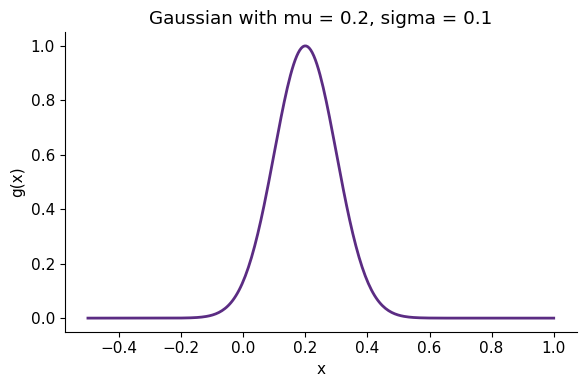

In [24]:
# TODO 1.4
# (1) Open src/qmn_utils.py in VS Code, paste the gaussian() function from section 1.5 into
#     it, and save the file. That is the only part you have to write yourself.
# (2) Then uncomment everything below and run this cell. The plot is already written for you,
#     so it will work as soon as the import succeeds.

# import importlib, src.qmn_utils
# importlib.reload(src.qmn_utils)
# from src.qmn_utils import gaussian as gaussian_from_module
#
# x = np.linspace(-0.5, 1.0, 300)
# fig, ax = plt.subplots()
# ax.plot(x, gaussian_from_module(x, mu=0.2, sigma=0.1), lw=2, color="#5b2c83")
# ax.set_xlabel("x")
# ax.set_ylabel("g(x)")
# ax.set_title("Gaussian, imported from src/qmn_utils.py")
# fig.tight_layout()
# plt.show()

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
import importlib
import src.qmn_utils
importlib.reload(src.qmn_utils)
# Once gaussian() has been pasted into the module, the line above makes it importable:
#     from src.qmn_utils import gaussian as gaussian_from_module
# Here we plot the copy defined in section 1.5, so that the notebook runs before that edit.

x = np.linspace(-0.5, 1.0, 300)
fig, ax = plt.subplots()
ax.plot(x, gaussian(x, mu=0.2, sigma=0.1), lw=2, color="#5b2c83")
ax.set_xlabel("x")
ax.set_ylabel("g(x)")
ax.set_title("Gaussian with mu = 0.2, sigma = 0.1")
fig.tight_layout()
plt.show()
# --- END SOLUTION

<a id="section-2"></a>
# Part 2. Calculus, numerically

In the lecture, derivatives and integrals were defined as limits. On a computer we never take a
limit: we have a function sampled at finitely many points, and we approximate. This part builds
those approximations and checks them against the analytic answers, which is the honest way to
find out how far you can trust them.

<a id="section-2-1"></a>
## 2.1 The derivative as a local slope

The derivative $f'(x)$ is the slope of $f$ at $x$: how much the output changes per unit of
input. Numerically, the slope between two neighbouring samples is

$$f'(x) \;\approx\; \frac{f(x+h) - f(x-h)}{2h}$$

which is what `np.gradient(y, x)` computes for every point of an array at once.

We test it on the Gaussian, whose analytic derivative we can write down:

$$g(x) = e^{-x^2/2\sigma^2} \quad\Longrightarrow\quad g'(x) = -\frac{x}{\sigma^2}\,g(x)$$

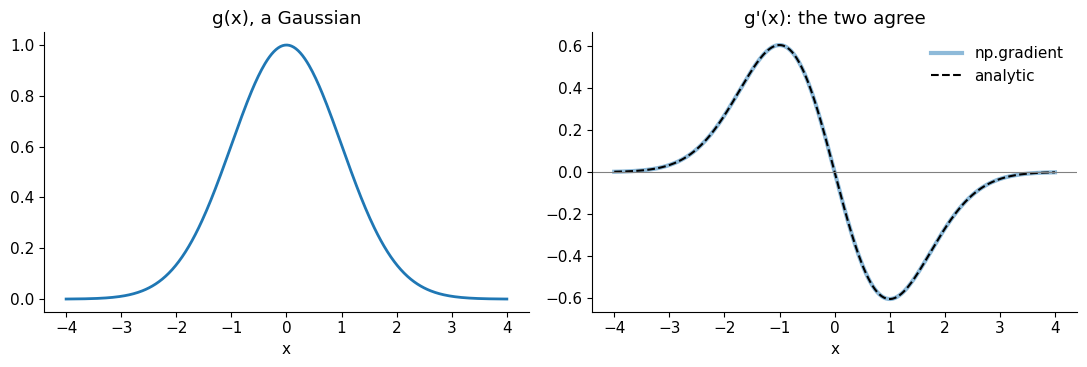

largest disagreement: 9.24e-05


In [25]:
# --- Numerical derivative vs the analytic one
x = np.linspace(-4, 4, 400)
g = gaussian(x, mu=0.0, sigma=1.0)

dg_numeric = np.gradient(g, x)          # slope at every point, from the samples
dg_analytic = -x * g                    # with sigma = 1

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(x, g, lw=2)
axes[0].set_title("g(x), a Gaussian")
axes[1].plot(x, dg_numeric, lw=3, alpha=0.5, label="np.gradient")
axes[1].plot(x, dg_analytic, lw=1.5, ls="--", color="black", label="analytic")
axes[1].axhline(0, color="gray", lw=0.8)
axes[1].set_title("g'(x): the two agree")
axes[1].legend(frameon=False)
for ax in axes:
    ax.set_xlabel("x")
fig.tight_layout()
plt.show()

print(f"largest disagreement: {np.abs(dg_numeric - dg_analytic).max():.2e}")

Notice where the derivative is zero: exactly at the peak of the Gaussian. That is the general
rule, a maximum or a minimum of $f$ is a **zero of $f'$**, and it is how optimisation
algorithms find peaks. Notice also that the derivative is largest in magnitude where the curve
is steepest, which is roughly one sigma either side of the centre.

The quality of the approximation depends on how finely you sample. With 400 points over 8 units
the agreement above is excellent. Try changing 400 to 40 and look at the number printed.

<a id="section-2-2"></a>
## 2.2 The second derivative: curvature

Differentiate twice and you get the **curvature**. The two signs tell you two different things:

- the sign of $f'$ says whether the function is **increasing** or **decreasing**;
- the sign of $f''$ says whether it is **convex** (curving upwards, like a valley) or
  **concave** (curving downwards, like a hill).

Where $f''$ crosses zero the curve changes its bending: that is an **inflexion point**. For the
sigmoid, that is exactly the midpoint, which is why the midpoint is also the steepest point.

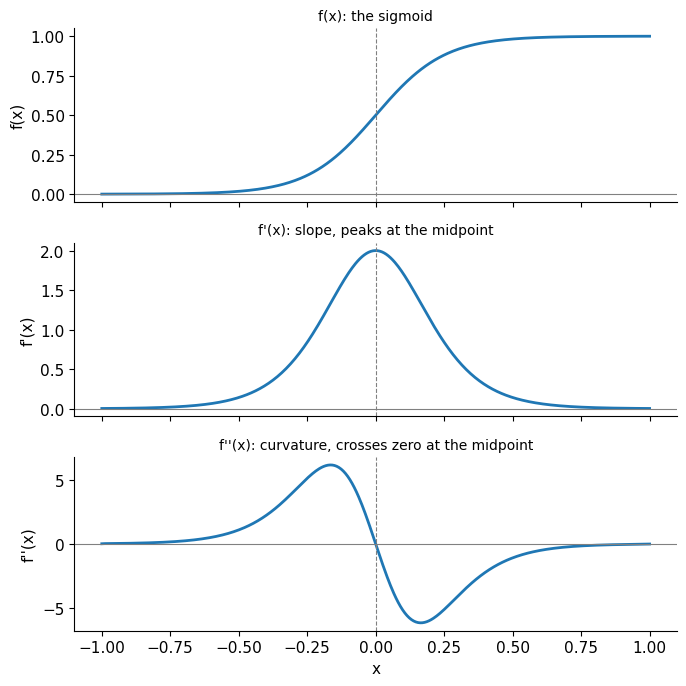

steepest slope, measured : 2.00
steepest slope, predicted (k/4): 2.00


In [26]:
# --- A sigmoid, its slope and its curvature, stacked
x = np.linspace(-1, 1, 500)
s = sigmoid(x, slope=8.0)
ds = np.gradient(s, x)
d2s = np.gradient(ds, x)

fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True)
for ax, y, name in zip(axes, [s, ds, d2s],
                       ["f(x): the sigmoid", "f'(x): slope, peaks at the midpoint",
                        "f''(x): curvature, crosses zero at the midpoint"]):
    ax.plot(x, y, lw=2)
    ax.axvline(0, color="gray", lw=0.8, ls="--")
    ax.axhline(0, color="gray", lw=0.8)
    ax.set_ylabel(name.split(":")[0])
    ax.set_title(name, fontsize=10)
axes[-1].set_xlabel("x")
fig.tight_layout()
plt.show()

print(f"steepest slope, measured : {ds.max():.2f}")
print(f"steepest slope, predicted (k/4): {8.0 / 4:.2f}")

<a id="section-2-3"></a>
## 2.3 The integral as accumulation

If the derivative is a rate, the integral is a **total**. The integral of $f$ between $a$ and
$b$ is the area under the curve, and the way to compute it numerically is to chop that area
into thin strips and add them up. `np.trapezoid` does that with trapezoidal strips.

Two different questions, two different tools:

- "what is the total?" is one number: `np.trapezoid(y, x)`;
- "how does the total build up along the way?" is a whole curve, the **cumulative** integral:
  `np.cumsum(y) * dx`.

We check the first against a case where we know the answer: a Gaussian with amplitude 1 and
width sigma has area $\sigma\sqrt{2\pi}$.

numeric area : 2.506628
analytic area: 2.506628
running area at several points (x,y pairs):
  (-6.00, 0.000000)
  (-3.60, 0.000412)
  (-1.20, 0.293730)
  (1.21, 2.224576)
  (3.61, 2.506253)


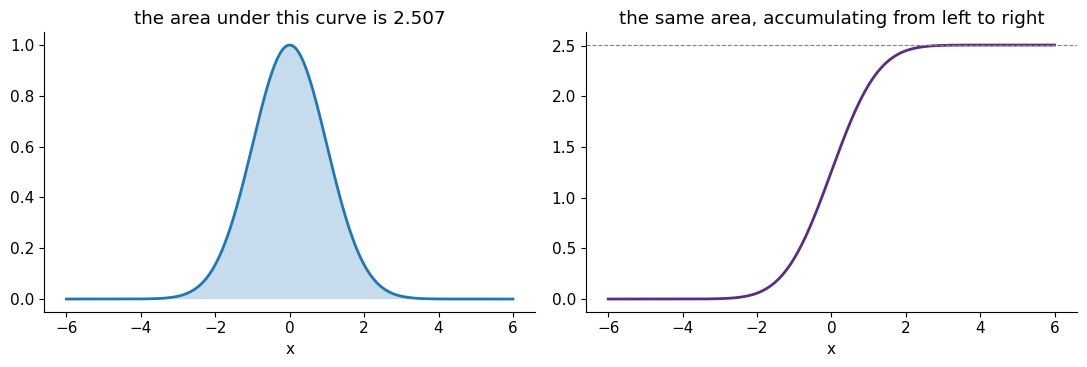

In [27]:
# --- Total area, and how it accumulates
# np.cumsum(...) * dt is the running sum of rectangles. Two neighbours worth knowing: np.trapz
# does the same total with trapezoids instead of rectangles, and np.diff is the raw difference
# between neighbouring samples, which is what np.gradient smooths over.
x = np.linspace(-6, 6, 1000)
dx = x[1] - x[0]
sigma = 1.0
g = gaussian(x, mu=0.0, sigma=sigma)

area_numeric = np.trapezoid(g, x) # the area under the curve, from the samples
area_analytic = sigma * np.sqrt(2 * np.pi) # the area under a Gaussian is known analytically
running_area = np.cumsum(g) * dx # the area accumulated up to each x

print(f"numeric area : {area_numeric:.6f}")
print(f"analytic area: {area_analytic:.6f}")
print(f"running area at several points (x,y pairs):")
for xi, yi in zip(x[::200], running_area[::200]):
    print(f"  ({xi:.2f}, {yi:.6f})")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(x, g, lw=2)
axes[0].fill_between(x, g, alpha=0.25)
axes[0].set_title(f"the area under this curve is {area_numeric:.3f}")
axes[1].plot(x, running_area, lw=2, color="#5b2c83")
axes[1].axhline(area_analytic, color="gray", lw=0.8, ls="--")
axes[1].set_title("the same area, accumulating from left to right")
for ax in axes:
    ax.set_xlabel("x")
fig.tight_layout()
plt.show()

<a id="section-2-4"></a>
## 2.4 The Fundamental Theorem of Calculus

The theorem says differentiation and integration undo each other. Integrate a function to get
its cumulative curve $F$, then differentiate $F$, and you are back to the function you started
from:

$$\frac{d}{dx}\int_a^x f(u)\,du \;=\; f(x)$$

This is not an abstraction: it is the statement that the *slope of the accumulated total* is
the *rate at which it is accumulating*. Speed and distance are the everyday version. Below we
check it numerically, which takes three lines.

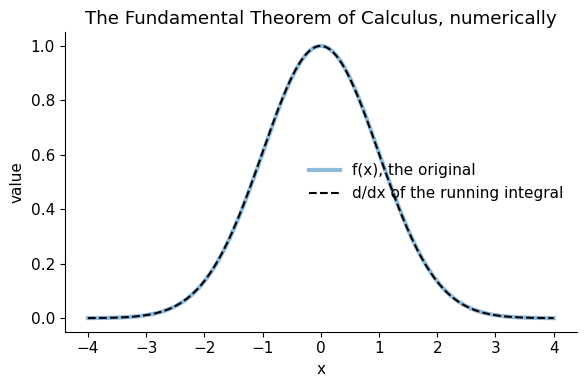

largest disagreement: 3.04e-03


In [28]:
# --- Integrate, then differentiate, and compare with the original
x = np.linspace(-4, 4, 800)
dx = x[1] - x[0]

f = gaussian(x, mu=0.0, sigma=1.0)
# get a running integral of f(x) from the left, using the trapezoid rule
F = np.cumsum(f) * dx
back = np.gradient(F, x)         # then differentiate

fig, ax = plt.subplots()
ax.plot(x, f, lw=3, alpha=0.5, label="f(x), the original")
ax.plot(x, back, lw=1.5, ls="--", color="black", label="d/dx of the running integral")
ax.set_xlabel("x"); ax.set_ylabel("value")
ax.set_title("The Fundamental Theorem of Calculus, numerically")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"largest disagreement: {np.abs(f - back).max():.2e}")

> **▶ Task 2.1 ⭐⭐ - Verify the theorem on a different function.**
> Repeat the check above for the **exponential decay** `exp_decay(t, amplitude=2, tau=0.8)` on
> `t` from 0 to 5 seconds with 600 points. Complete the three missing lines below, plot the
> original against the differentiated running integral, and print the largest disagreement.
>
> Then answer in a comment: the disagreement is largest at one end of the interval. Which end,
> and why? (Hint: think about what `np.gradient` can do at the very first and very last point,
> where it has a neighbour on only one side.)

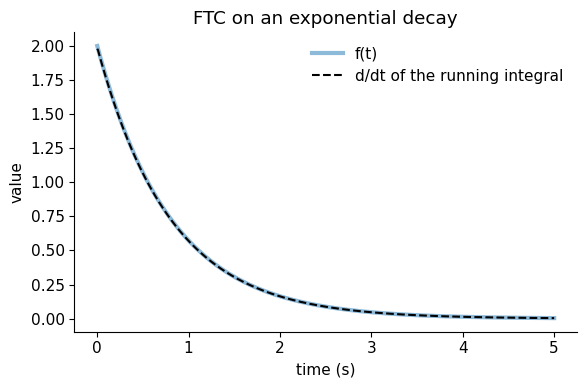

largest disagreement: 2.08e-02


In [29]:
# TODO 2.1 - fill in the three blanks marked ____, uncomment, and run.
# t = np.linspace(0, 5, 600)
# dt = t[1] - t[0]
#
# f = ____                     # (1) exp_decay evaluated on t, with amplitude 2 and tau 0.8
# F = ____                     # (2) accumulate it:  np.cumsum(...) * dt
# back = ____                  # (3) differentiate the accumulation:  np.gradient(..., t)
#
# --- the figure and the check are written for you
# fig, ax = plt.subplots()
# ax.plot(t, f, lw=3, alpha=0.5, label="f(t)")
# ax.plot(t, back, lw=1.5, ls="--", color="black", label="d/dt of the running integral")
# ax.set_xlabel("time (s)"); ax.set_ylabel("value")
# ax.set_title("FTC on an exponential decay")
# ax.legend(frameon=False)
# fig.tight_layout()
# plt.show()
# print(f"largest disagreement: {np.abs(f - back).max():.2e}")

# Then answer here: at which end of the interval is the disagreement largest, and why?

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
t = np.linspace(0, 5, 600)
dt = t[1] - t[0]

f = exp_decay(t, amplitude=2.0, tau=0.8)
F = np.cumsum(f) * dt
back = np.gradient(F, t)

fig, ax = plt.subplots()
ax.plot(t, f, lw=3, alpha=0.5, label="f(t)")
ax.plot(t, back, lw=1.5, ls="--", color="black", label="d/dt of the running integral")
ax.set_xlabel("time (s)"); ax.set_ylabel("value")
ax.set_title("FTC on an exponential decay")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"largest disagreement: {np.abs(f - back).max():.2e}")
# The disagreement is largest at the left edge, t = 0. np.gradient uses a one-sided difference
# at the very first and very last sample instead of a centred one, and the curve is steepest at
# t = 0, so that is where the cruder formula costs the most.
# --- END SOLUTION

<a id="section-2-5"></a>
## 2.5 Local linearization: Taylor to first order

Near a point $x_0$, any smooth function looks like a straight line. The **first-order Taylor
approximation** is that line:

$$f(x) \;\approx\; f(x_0) + f'(x_0)\,(x - x_0)$$

It is the tangent at $x_0$. This is the idea behind a great deal of applied maths: replace an
awkward function by a line, valid as long as you do not stray too far. The interesting question
is always *how far is too far*, and the answer is visible in a plot.

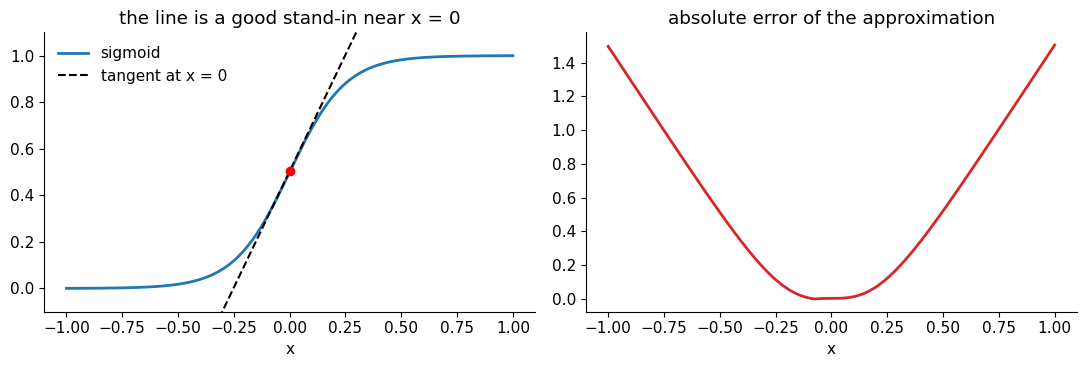

within +/- 0.05: largest error 0.0050
within +/- 0.1: largest error 0.0135
within +/- 0.3: largest error 0.1851


In [30]:
# --- A sigmoid and its tangent at the midpoint, plus the error
x = np.linspace(-1, 1, 500)
s = sigmoid(x, slope=8.0)
ds = np.gradient(s, x)

x0 = 0.0
i0 = np.argmin(np.abs(x - x0))                       # index of the point nearest x0
tangent = s[i0] + ds[i0] * (x - x0)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(x, s, lw=2, label="sigmoid")
axes[0].plot(x, tangent, lw=1.5, ls="--", color="black", label="tangent at x = 0")
axes[0].plot(x0, s[i0], "o", color="red", ms=6)
axes[0].set_ylim(-0.1, 1.1)
axes[0].set_title("the line is a good stand-in near x = 0")
axes[0].legend(frameon=False)

axes[1].plot(x, np.abs(s - tangent), lw=2, color="#d62728")
axes[1].set_title("absolute error of the approximation")
for ax in axes:
    ax.set_xlabel("x")
fig.tight_layout()
plt.show()

for width in [0.05, 0.1, 0.3]:
    inside = np.abs(x - x0) < width
    print(f"within +/- {width}: largest error {np.abs(s - tangent)[inside].max():.4f}")

> **▶ Task 2.2 ⭐⭐ - Where does the line stop working?**
> Using the printout above as a model, find (roughly) how far from `x = 0` you can go before
> the tangent is wrong by more than 0.02, for a sigmoid with `slope = 8`. Then repeat for
> `slope = 20`. Does a steeper sigmoid give you a wider or a narrower region where the linear
> approximation is good? Explain the answer in one sentence.

In [31]:
# TODO 2.2 - fill in the two blanks marked ____, uncomment, and run.
# x = np.linspace(-1, 1, 2001)
#
# for k in [8.0, 20.0]:
#     s = sigmoid(x, slope=k)
#     ds = np.gradient(s, x)
#     i0 = np.argmin(np.abs(x))          # index of the point at x = 0
#     tangent = s[i0] + ds[i0] * x
#
#     error = ____                       # (1) absolute difference between s and tangent
#     good = ____                        # (2) the largest |x| where error stays below 0.02
#                                        #     hint: np.abs(x)[error <= 0.02].max()
#     print(f"slope k = {k:4.1f}: the tangent stays within 0.02 up to about +/- {good:.3f}")

# Then answer here: does a steeper sigmoid give a wider or a narrower good region, and why?

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
x = np.linspace(-1, 1, 2001)

for k in [8.0, 20.0]:
    s = sigmoid(x, slope=k)
    ds = np.gradient(s, x)
    i0 = np.argmin(np.abs(x))
    tangent = s[i0] + ds[i0] * x

    error = np.abs(s - tangent)
    good = np.abs(x)[error <= 0.02].max()
    print(f"slope k = {k:4.1f}: the tangent stays within 0.02 up to about +/- {good:.3f}")

# The steeper sigmoid has the narrower good region. A larger k means the curve bends away from
# its own tangent more sharply, so the straight-line approximation fails closer to the midpoint.
# --- END SOLUTION

slope k =  8.0: the tangent stays within 0.02 up to about +/- 0.127
slope k = 20.0: the tangent stays within 0.02 up to about +/- 0.050


<a id="section-3"></a>
# Part 3. Putting it together on generated signals

Two miniature analyses on signals we build ourselves. Both are the shape of something you will
do for real later in the course: measure a parameter from a trace, and take a compound signal
apart.

<a id="section-3-1"></a>
## 3.1 A calcium transient

When a neuron fires, a calcium indicator such as GCaMP brightens quickly and then decays back
to baseline roughly exponentially. The decay time constant is a property of the indicator and
of the cell, and reading it off a trace is a standard measurement.

We build a transient as a fast rise multiplied by a slow decay, add a little measurement noise,
and then recover tau from the noisy trace.

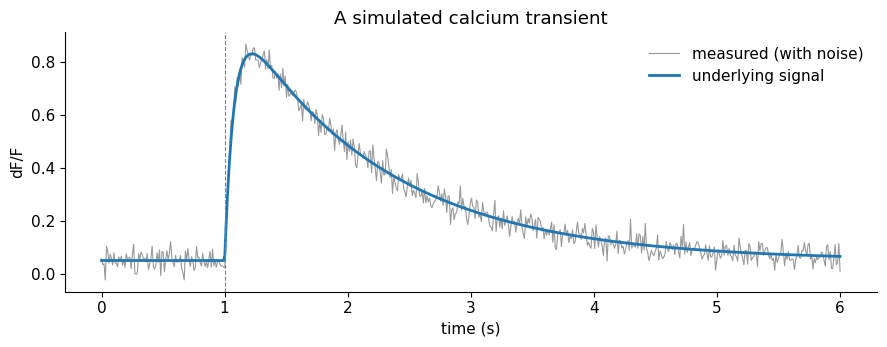

In [32]:
# --- Build a noisy calcium transient
rng = np.random.default_rng(2)

t = np.linspace(0, 6, 600)          # six seconds, 600 samples
t_onset, tau_rise, tau_decay = 1.0, 0.08, 1.2   # the spike happens at 1 s; rise fast, decay slow
amplitude, baseline = 1.0, 0.05                 # how far it climbs, and where it sits at rest

# A mask: True for every sample after the spike, False before it. Nothing happens before onset.
after = t >= t_onset

# Start from a flat trace sitting at the baseline everywhere, the same shape as t.
clean = np.full_like(t, baseline)

# After the onset the trace is the product of two exponentials, which is the standard shape of a
# calcium transient: one term climbing from 0 to 1 with the fast time constant tau_rise, and one
# falling back towards 0 with the slow tau_decay. Fast in, slow out.
rise = 1 - np.exp(-(t[after] - t_onset) / tau_rise)
decay = np.exp(-(t[after] - t_onset) / tau_decay)
clean[after] = baseline + amplitude * rise * decay

# Real recordings are noisy, so add a little Gaussian measurement noise on top.
noisy = clean + rng.normal(0, 0.03, size=t.size)

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(t, noisy, lw=0.8, color="0.6", label="measured (with noise)")
ax.plot(t, clean, lw=2, label="underlying signal")
ax.axvline(t_onset, color="gray", lw=0.8, ls="--")
ax.set_xlabel("time (s)"); ax.set_ylabel("dF/F")
ax.set_title("A simulated calcium transient")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

To measure the decay we use the log trick from section 1.5: an exponential decay is a straight
line on a logarithmic y axis, and the slope of that line is $-1/\tau$. So we take the part of
the trace after the peak, subtract the baseline, take the logarithm, and fit a line to it with
`np.polyfit`.

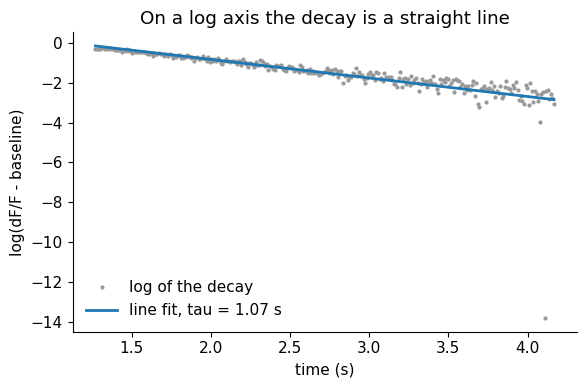

true tau      : 1.20 s
estimated tau : 1.07 s
half-life     : 0.74 s


In [33]:
# --- Recover the decay time constant from the noisy trace
peak_index = np.argmax(noisy)
# choose a region after the peak, but not too far out where the signal is lost in noise
decay_region = (t > t[peak_index] + 0.1) & (t < t[peak_index] + 3.0)

y = noisy[decay_region] - baseline
# logs need strictly positive values, clip to a small positive number to avoid log(0)
y = np.clip(y, 1e-6, None)
# fit a straight line to the log of the decay, arguments are x and y, 1 means linear fit
slope, intercept = np.polyfit(t[decay_region], np.log(y), 1)
tau_estimated = -1 / slope

fig, ax = plt.subplots()
ax.plot(t[decay_region], np.log(y), ".", ms=4, color="0.6", label="log of the decay")
ax.plot(t[decay_region], slope * t[decay_region] + intercept, lw=2,
        label=f"line fit, tau = {tau_estimated:.2f} s")
ax.set_xlabel("time (s)"); ax.set_ylabel("log(dF/F - baseline)")
ax.set_title("On a log axis the decay is a straight line")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"true tau      : {tau_decay:.2f} s")
print(f"estimated tau : {tau_estimated:.2f} s")
print(f"half-life     : {tau_estimated * np.log(2):.2f} s")

The estimate comes out a little short of the true 1.2 s. That is not a bug: the window we fitted
starts only 0.1 s after the peak, so it still contains a trace of the rising phase, which pulls
the apparent decay faster. Push the start of `decay_region` later and the estimate creeps up
towards the true value, at the cost of fitting fewer and noisier points. Choosing that window is
a real experimental judgement call, not a detail.

> **▶ Task 3.1 ⭐⭐ - The rate of change of the transient.**
> Compute the numerical derivative of the **clean** transient with `np.gradient` and plot it
> under the signal, sharing the x axis. Then answer in comments:
> 1. at what time is the derivative largest, and what is happening to the signal there?
> 2. where does the derivative cross zero, and what does that instant correspond to?

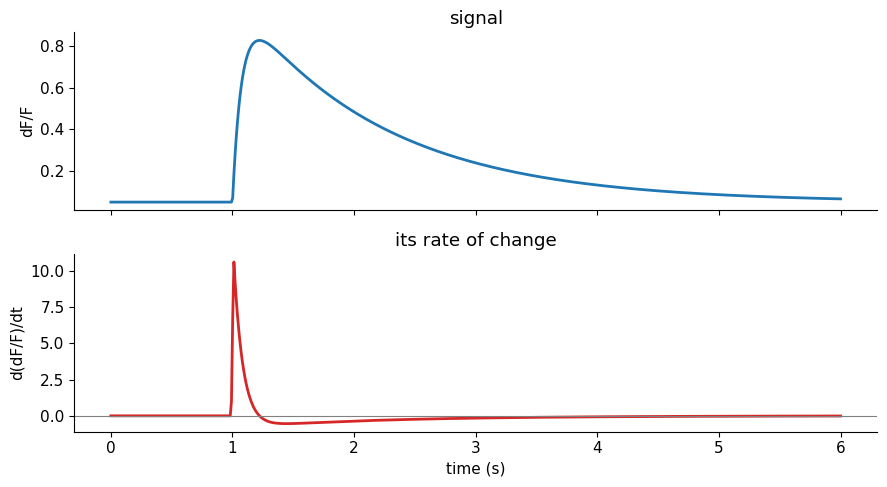

the derivative is largest at t = 1.01
the signal peaks at        t = 1.22


In [34]:
# TODO 3.1 - fill in the three blanks marked ____, uncomment, and run.
# rate = ____                    # (1) numerical derivative of `clean` with respect to t
#
# --- the figure is written for you
# fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
# axes[0].plot(t, clean, lw=2)
# axes[0].set_ylabel("dF/F"); axes[0].set_title("signal")
# axes[1].plot(t, rate, lw=2, color="#d62728")
# axes[1].axhline(0, color="gray", lw=0.8)
# axes[1].set_ylabel("d(dF/F)/dt"); axes[1].set_xlabel("time (s)")
# axes[1].set_title("its rate of change")
# fig.tight_layout()
# plt.show()
#
# print("the derivative is largest at t =", ____)    # (2) hint: t[np.argmax(...)]
# print("the signal peaks at        t =", ____)      # (3) the same idea, on the signal itself

# Then answer here: 1. what is happening to the signal where the derivative is largest?
#                   2. what does the instant where the derivative crosses zero correspond to?

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
rate = np.gradient(clean, t)

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(t, clean, lw=2)
axes[0].set_ylabel("dF/F"); axes[0].set_title("signal")
axes[1].plot(t, rate, lw=2, color="#d62728")
axes[1].axhline(0, color="gray", lw=0.8)
axes[1].set_ylabel("d(dF/F)/dt"); axes[1].set_xlabel("time (s)")
axes[1].set_title("its rate of change")
fig.tight_layout()
plt.show()

print("the derivative is largest at t =", round(float(t[np.argmax(rate)]), 2))
print("the signal peaks at        t =", round(float(t[np.argmax(clean)]), 2))
# 1. The derivative peaks just after onset, during the fast rise: that is where the signal is
#    climbing quickest, which is not where it is highest.
# 2. It crosses zero at the peak of the transient. A zero of the derivative is a maximum of the
#    signal, exactly as in section 2.1.
# --- END SOLUTION

<a id="section-3-2"></a>
## 3.2 An EEG-like signal

A recorded brain signal is a sum of rhythms at different frequencies, plus noise. Here we build
one by adding three sinusoids, and then look at what the sum hides. In Week 13 you will
take a real EEG trace apart with the Fourier transform; this is the intuition that makes that
possible.

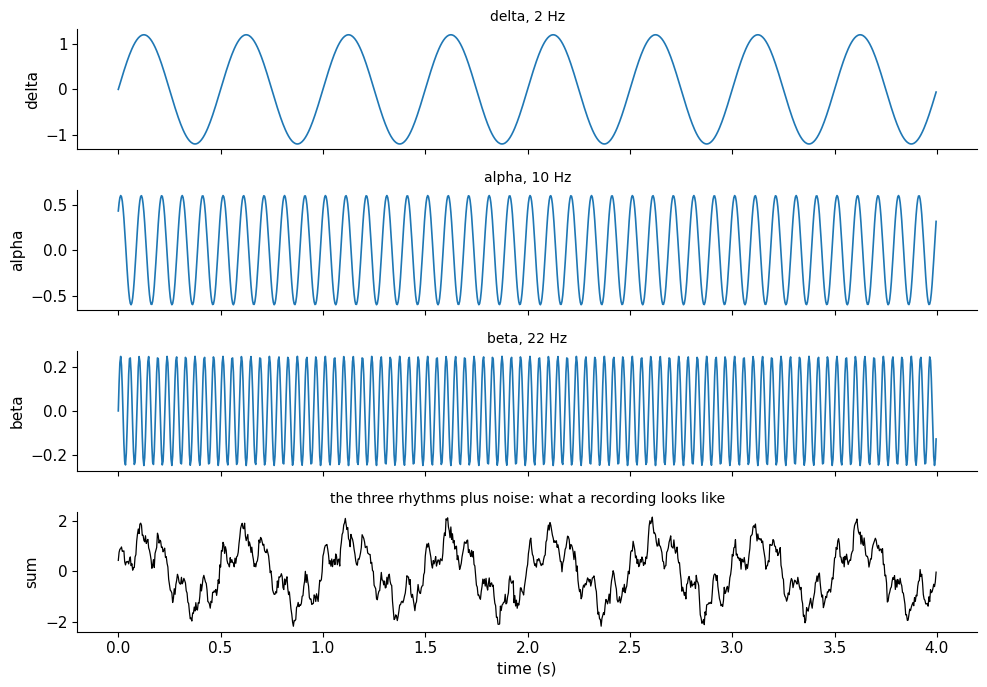

1024 samples at 256 Hz, so one sample every 3.91 ms


In [35]:
# --- A synthetic EEG trace: three rhythms plus noise
rng = np.random.default_rng(7)

fs = 256.0                                  # sampling rate, in Hz
t = np.arange(0, 4, 1 / fs)                 # 4 seconds

components = {
    "delta, 2 Hz":  1.20 * np.sin(2 * np.pi * 2 * t),
    "alpha, 10 Hz": 0.60 * np.sin(2 * np.pi * 10 * t + 0.8),
    "beta, 22 Hz":  0.25 * np.sin(2 * np.pi * 22 * t),
}
noise = rng.normal(0, 0.15, size=t.size)
signal = sum(components.values()) + noise

fig, axes = plt.subplots(4, 1, figsize=(10, 7), sharex=True)
for ax, (name, comp) in zip(axes, components.items()):
    ax.plot(t, comp, lw=1.2)
    ax.set_ylabel(name.split(",")[0])
    ax.set_title(name, fontsize=10)
axes[-1].plot(t, signal, lw=0.9, color="black")
axes[-1].set_ylabel("sum")
axes[-1].set_title("the three rhythms plus noise: what a recording looks like", fontsize=10)
axes[-1].set_xlabel("time (s)")
fig.tight_layout()
plt.show()

print(f"{t.size} samples at {fs:.0f} Hz, so one sample every {1000 / fs:.2f} ms")

Look at the bottom panel and try to read the individual rhythms off it. The 2 Hz wave is
obvious, the 10 Hz one is arguably visible, and the 22 Hz one is essentially invisible even
though we know it is there because we put it there. That gap between "present" and "visible" is
the reason the frequency-domain tools exist.

> **▶ Task 3.2 ⭐⭐⭐ - What differentiation does to a rhythm.**
> Differentiating a sinusoid gives another sinusoid of the same frequency, but its amplitude is
> multiplied by $2\pi f$. Fast rhythms are therefore boosted far more than slow ones, and you can
> watch it happen on the signal above.
>
> 1. Add a fourth component to `components`, a 40 Hz rhythm with amplitude 0.2, and rebuild the
>    summed signal.
> 2. Take its numerical derivative with `np.gradient`.
> 3. Plot the signal and its derivative one above the other, sharing the time axis.
> 4. For each component, print its amplitude and the amplitude of its derivative.
>
> Then answer in a comment: which rhythm dominates the signal, and which dominates the
> derivative? This is why differentiating a noisy recording is usually a bad idea, and it is a
> first glimpse of the Fourier week: differentiation acts as a high-pass filter.

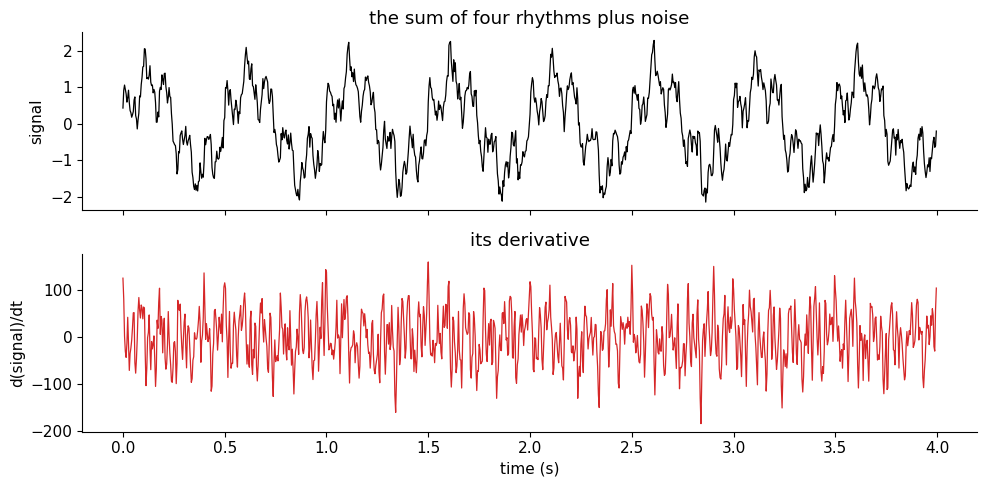

delta, 2 Hz    amplitude  1.20   derivative    15.1
alpha, 10 Hz   amplitude  0.60   derivative    37.3
beta, 22 Hz    amplitude  0.25   derivative    32.9
gamma, 40 Hz   amplitude  0.20   derivative    42.6


In [36]:
# TODO 3.2 - fill in the blanks marked ____, uncomment, and run.
# components["gamma, 40 Hz"] = ____              # (1) 0.2 * a 40 Hz sine, like the ones above
# signal_4 = sum(components.values()) + noise
# rate = ____                                    # (2) derivative of signal_4 with respect to t
#
# fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
# axes[0].plot(t, signal_4, lw=0.9, color="black")
# axes[0].set_ylabel("signal"); axes[0].set_title("the sum of four rhythms plus noise")
# axes[1].plot(t, rate, lw=0.9, color="#d62728")
# axes[1].set_ylabel("d(signal)/dt"); axes[1].set_xlabel("time (s)")
# axes[1].set_title("its derivative")
# fig.tight_layout()
# plt.show()
#
# (3) one line per component: how big is it, and how big is its derivative?
# for name, comp in components.items():
#     print(f"{name:14s} amplitude {np.abs(comp).max():5.2f}   "
#           f"derivative {np.abs(np.gradient(comp, t)).max():7.1f}")

# Then answer here: which rhythm dominates the signal, and which dominates the derivative?

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
components["gamma, 40 Hz"] = 0.2 * np.sin(2 * np.pi * 40 * t)
signal_4 = sum(components.values()) + noise
rate = np.gradient(signal_4, t)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t, signal_4, lw=0.9, color="black")
axes[0].set_ylabel("signal"); axes[0].set_title("the sum of four rhythms plus noise")
axes[1].plot(t, rate, lw=0.9, color="#d62728")
axes[1].set_ylabel("d(signal)/dt"); axes[1].set_xlabel("time (s)")
axes[1].set_title("its derivative")
fig.tight_layout()
plt.show()

for name, comp in components.items():
    print(f"{name:14s} amplitude {np.abs(comp).max():5.2f}   "
          f"derivative {np.abs(np.gradient(comp, t)).max():7.1f}")

# The 2 Hz delta rhythm dominates the signal: it has the largest amplitude by far. In the
# derivative the order is reversed and the 40 Hz component dominates, even though it is the
# smallest of the four, because differentiating multiplies each amplitude by 2*pi*f. The noise,
# which changes from one sample to the next, is amplified hardest of all.
# --- END SOLUTION

<a id="section-3-3"></a>
## 3.3 How good is that estimate?

Section 3.1 recovered a decay time constant from one noisy trace and got 1.13 s where the truth was
1.2 s. One trace tells you nothing about how reliable that is: to find out, you have to repeat the
measurement many times and look at the spread of the answers. That is the whole idea behind the
next two weeks, and here it costs three lines of loop.

Two small functions do the work, and neither is new: the first is the transient of section 3.1 with
the noise level as an argument, the second is the log-linear fit of section 3.1 wrapped up so that
it can be called many times. Run this cell, then use them in the task below.

In [37]:
# --- The two tools for the experiment below
def make_transient(noise_sd, rng):
    """One noisy calcium transient, with the same parameters as section 3.1."""
    t = np.linspace(0, 6, 600)
    after = t >= 1.0
    clean = np.full_like(t, 0.05)
    rise = 1 - np.exp(-(t[after] - 1.0) / 0.08)
    decay = np.exp(-(t[after] - 1.0) / 1.2)
    clean[after] = 0.05 + rise * decay
    return t, clean + rng.normal(0, noise_sd, size=t.size)

def recover_tau(t, trace, baseline=0.05):
    """Estimate the decay time constant by fitting a line to the log of the decay."""
    peak = np.argmax(trace)
    window = (t > t[peak] + 0.1) & (t < t[peak] + 3.0)
    y = np.clip(trace[window] - baseline, 1e-6, None)
    slope, _ = np.polyfit(t[window], np.log(y), 1)
    return -1 / slope

> **▶ Task 3.3 ⭐⭐⭐ - How good is that estimate?**
> With `make_transient` and `recover_tau` in hand, run the experiment:
>
> 1. for each of three noise levels, say `0.01`, `0.03` and `0.10`, generate **200** noisy
>    transients and estimate tau from each one;
> 2. print, for each level, the mean estimate and its spread, next to the true value of 1.2 s;
> 3. draw the three sets of estimates side by side, so that the growth of the spread is visible.
>
> Then answer in a comment: as the noise grows, does the estimate become **wrong**, or merely
> **uncertain**, or both? The distinction matters, and next week it gets the names bias and
> variance.

true tau = 1.20 s

 noise SD   mean estimate   spread (SD)     bias
     0.01           1.196         0.009   -0.004
     0.03           1.148         0.044   -0.052
     0.10           0.576         0.077   -0.624


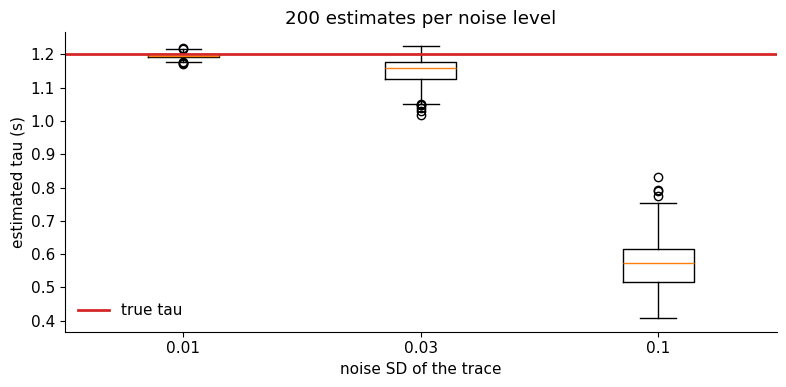

In [38]:
# TODO 3.3 - your experiment here

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
rng = np.random.default_rng(7)
true_tau = 1.2
noise_levels = [0.01, 0.03, 0.10]
estimates = {}

for noise_sd in noise_levels:
    values = []
    for _ in range(200):
        t, trace = make_transient(noise_sd, rng)
        values.append(recover_tau(t, trace))
    estimates[noise_sd] = np.array(values)

print(f"true tau = {true_tau:.2f} s\n")
print(f"{'noise SD':>9} {'mean estimate':>15} {'spread (SD)':>13} {'bias':>8}")
for noise_sd, values in estimates.items():
    print(f"{noise_sd:>9.2f} {values.mean():>15.3f} {values.std(ddof=1):>13.3f} "
          f"{values.mean() - true_tau:>8.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([estimates[s] for s in noise_levels], tick_labels=[str(s) for s in noise_levels])
ax.axhline(true_tau, color="#d62728", lw=2, label="true tau")
ax.set_xlabel("noise SD of the trace")
ax.set_ylabel("estimated tau (s)")
ax.set_title("200 estimates per noise level")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

# Both, and the two grow very differently. At the lowest noise the estimates are tight (spread
# 0.009 s) and almost unbiased (mean 1.196 against a true 1.2). Multiply the noise by ten and the
# spread grows about eightfold, which is the expected VARIANCE cost, but the mean estimate collapses
# to 0.58 s: the method has become systematically WRONG, not merely uncertain. That offset is a
# BIAS, and it comes from the tail of the fitting window, where the signal has almost died away and
# what is left is mostly noise around the baseline. Values that fall below the baseline get clipped
# before the logarithm, which drags the fitted line steeper and the estimated tau shorter.
#
# The distinction matters because the two have different cures. Variance shrinks if you average
# more traces. Bias does not: a thousand noisy traces would give you 0.58 s very precisely. The
# cure for the bias is to fit a shorter window, or to stop trusting the log-linear trick at this
# noise level at all.
# --- END SOLUTION

<a id="section-4"></a>
# 4. What comes next

You now have the two habits the rest of the course rests on: build the object, then plot it and
look at it. Specifically, you can write a vectorized function, dress a figure properly, and
compute a derivative or an integral without an analytic formula.

Three threads from today continue directly:

- The **sigmoid** returns in Week 3 as the psychometric curve of a mouse making decisions,
  with its midpoint becoming a perceptual threshold.
- The **exponential decay** returns whenever something relaxes back to a baseline, and the log
  trick from section 3.1 is how it gets measured.
- The **sum of sinusoids** from section 3.2 is where the EEG weeks begin, and the biased tau
  estimate in section 3.3 is the first sampling distribution of the course, which is the subject
  of Week 3.

Next week we stop generating our own data and open a real one: the behaviour of 30 mice
learning a visual decision task.